<a href="https://colab.research.google.com/github/czovekboti/ABT-MLHF/blob/main/Ship_Detection_Notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Airbus Ship Detection – U-Net training notebook

This notebook trains a segmentation model to detect ships in satellite images from the Kaggle *Airbus Ship Detection* dataset.

# Get dataset(kaggle case)

If you already have the dataset on the server, keep `DOWNLOAD_DATASET=False`.

For Kaggle download to work you typically need a `kaggle.json` API token in the working directory (or configured via `KAGGLE_CONFIG_DIR`).

In [ ]:
DOWNLOAD_DATASET = False # set True only if you want to download dataset
if DOWNLOAD_DATASET is True:
    import os
    os.environ['KAGGLE_CONFIG_DIR'] = r"./"
    !pip install kaggle
    !kaggle competitions download -c airbus-ship-detection -p .
    import zipfile
    import os

    zip_path = "airbus-ship-detection.zip"
    extract_dir = "./airbus_data"

    # Make sure target folder exists
    os.makedirs(extract_dir, exist_ok=True)

    # Extract with progress info
    with zipfile.ZipFile(zip_path, "r") as zip_ref:
        print(f"Extracting {len(zip_ref.infolist())} files...")
        zip_ref.extractall(extract_dir)

    print("✅ Extraction complete.")

## 2) Load metadata CSV

`train_ship_segmentations_v2.csv` contains one row per ship instance. Images with no ships have `EncodedPixels = NaN`.


In [ ]:
import pandas as pd
import os

# Load CSV into a DataFrame
DATA_DIR      = './airbus_data/'
TRAIN_IMG_DIR = os.path.join(DATA_DIR, "train_v2")
TEST_IMG_DIR  = os.path.join(DATA_DIR, "test_v2")
train_csv = os.path.join(DATA_DIR, 'train_ship_segmentations_v2.csv')
train_df = pd.read_csv(train_csv)
print(train_df.shape)
train_df.head()


(231723, 2)


,ImageId,EncodedPixels
0,00003e153.jpg,NaN
1,0001124c7.jpg,NaN
2,000155de5.jpg,264661 17 265429 33 266197 33 266965 33 267733...
3,000194a2d.jpg,360486 1 361252 4 362019 5 362785 8 363552 10 ...
4,000194a2d.jpg,51834 9 52602 9 53370 9 54138 9 54906 9 55674 ...


## 3) Quick sanity checks / cleaning

- Count missing masks (no ships)
- Remove duplicate rows
- Optionally verify that image files exist


In [ ]:
# Missing values (if no ship -> encoded pixels is nan)
missing_masks = train_df['EncodedPixels'].isnull().sum()
print("Pictures without boats:", missing_masks)
not_missing_masks = train_df['EncodedPixels'].notnull().sum()
print("Pictures with boats", not_missing_masks)
# One picture can have more masks -> needs grouping
unique_images = train_df['ImageId'].nunique()
print("Unique pictures:", unique_images)


Pictures without boats: 150000
Pictures with boats 81723
Unique pictures: 192556


In [ ]:
# Filter duplications
train_df = train_df.drop_duplicates(subset=['ImageId', 'EncodedPixels'])
# Checking actual existance of files
train_images = set(os.listdir(os.path.join(DATA_DIR, 'train_v2')))
train_df = train_df[train_df['ImageId'].isin(train_images)]
train_df.head()

,ImageId,EncodedPixels
0,00003e153.jpg,NaN
1,0001124c7.jpg,NaN
2,000155de5.jpg,264661 17 265429 33 266197 33 266965 33 267733...
3,000194a2d.jpg,360486 1 361252 4 362019 5 362785 8 363552 10 ...
4,000194a2d.jpg,51834 9 52602 9 53370 9 54138 9 54906 9 55674 ...


In [ ]:
# Labeling(1 if has ship else 0)
train_df['has_ship'] = train_df['EncodedPixels'].notnull().astype(int)

# Group all rows that belong to same image
image_grouped = train_df.groupby('ImageId')['has_ship'].max().reset_index()
image_grouped.rename(columns={'has_ship': 'has_ship_label'}, inplace=True)

# Balancing due to lot of empty pictures -> 1:2 ratio of has ships and no ships so it doesnt overfit.
positive = image_grouped[image_grouped['has_ship_label'] == 1]
negative = image_grouped[image_grouped['has_ship_label'] == 0].sample(len(positive) * 2, random_state=42)
balanced_df = pd.concat([positive, negative])

## 4) RLE decoding

Kaggle stores masks as run-length encoding (RLE). We decode it into a 2D binary mask.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
# Take in rle string and output binary mask with given shape
def rle_decode(mask_rle, shape=(768, 768)):
    # Return full black mask if RLE is missing
    if pd.isnull(mask_rle):
        return np.zeros(shape, dtype=np.uint8)

    s = mask_rle.split()
    # RLE odd nums -> length even nums-> start values
    starts, lengths = [np.asarray(x, dtype=int) for x in (s[::2], s[1::2])]
    starts -= 1
    ends = starts + lengths
    img = np.zeros(shape[0]*shape[1], dtype=np.uint8)
    for lo, hi in zip(starts, ends):
        img[lo:hi] = 1
    return img.reshape(shape).T  # Transpose to align with right direction


# 5) Train/val/test split (image-level)

We split by `ImageId` to avoid leaking masks of the same image across splits.


In [ ]:
from sklearn.model_selection import train_test_split
# split into TRAIN(90%) and TEMP(10%)
train_df, temp_df = train_test_split(
    balanced_df,
    test_size=0.1,
    random_state=42,
    stratify=balanced_df["has_ship_label"] # ensure that we keep the same ratio of ships/no-ships pictures
)
# split TEMP INTO VALIDATION(5%) AND TEST(5%)
val_df, test_df = train_test_split(
    temp_df,
    test_size=0.5,
    random_state=42,
    stratify=temp_df['has_ship_label']
)

train_ids = train_df['ImageId'].values
val_ids = val_df['ImageId'].values
test_ids = test_df['ImageId'].values

print(f"Total Balanced Images: {len(balanced_df)}")
print(f"---------------------------------------")
print(f"Train Size (90%): {len(train_ids)} images")
print(f"Val Size    (5%): {len(val_ids)} images")
print(f"Test Size   (5%): {len(test_ids)} images")

Total Balanced Images: 127668
---------------------------------------
Train Size (90%): 114901 images
Val Size    (5%): 6383 images
Test Size   (5%): 6384 images


## Custom PyTorch Dataset for Airbus Ship Detection
**__init__:**
- Stores the input dataframe (df) and image directory path (base_path).
- Loads the CSV containing all RLE-encoded masks.
- Saves any optional augmentations or preprocessing transforms (e.g., resize, normalize).
**__getitem__:**
- Retrieves the image filename using the given index.
- Opens the corresponding image and converts it to RGB.
- Collects all mask rows belonging to that image ID, decodes them from RLE, and merges them into one binary mask (768×768).
- Applies Albumentations transforms jointly on the image and mask to keep them spatially consistent.
- Returns the processed (image, mask) pair as tensors ready for model input.

In [ ]:
from torch.utils.data import Dataset
from PIL import Image
import torch
import numpy as np
import os
import pandas as pd

class AirbusDataset(Dataset):
    def __init__(self, image_ids, img_dir, mask_df, transforms=None):
        self.image_ids = image_ids
        self.img_dir = img_dir
        self.transforms = transforms
        self.mask_groups = mask_df.groupby('ImageId')

    def __len__(self):
        return len(self.image_ids)

    def __getitem__(self, idx):
        img_name = self.image_ids[idx]
        img_path = os.path.join(self.img_dir, img_name)

        # 1. Load Image
        try:
            image = np.array(Image.open(img_path).convert("RGB"))
        except Exception as e:
            print(f"Warning: Error loading {img_name}, using empty mask.")
            image = np.zeros((768, 768, 3), dtype=np.uint8)

        # 2. Get Masks (Fast Lookup)
        try:
            img_masks = self.mask_groups.get_group(img_name)
        except KeyError:
            img_masks = pd.DataFrame()

        # 3. Decode RLE
        mask = np.zeros((768, 768), dtype=np.float32)
        if not img_masks.empty:
            for _, row in img_masks.iterrows():
                if isinstance(row['EncodedPixels'], str):
                    mask += rle_decode(row['EncodedPixels'])

        mask = np.clip(mask, 0, 1)

        # 4. Augmentations
        if self.transforms:
            augmented = self.transforms(image=image, mask=mask)
            image = augmented['image']
            mask = augmented['mask']

        return image, mask

Training Set Size: 114901


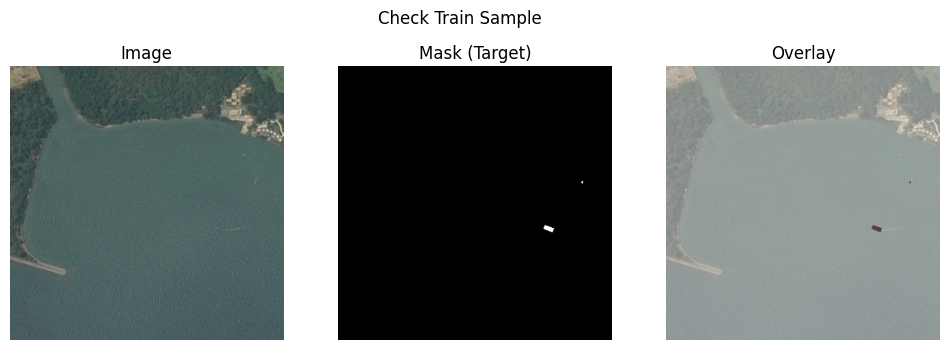

In [ ]:
# 1. Reload the full mask data (we need the RLE strings)
masks = pd.read_csv(os.path.join(DATA_DIR, 'train_ship_segmentations_v2.csv'))

# 2. Define Augmentations (Standard ImageNet stats help convergence)
import albumentations as A
from albumentations.pytorch import ToTensorV2

IMG_SIZE = 384

train_transforms = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.HorizontalFlip(p=0.5),
    A.RandomBrightnessContrast(p=0.2),
    # Normalize inputs to 0-1 range using standard ImageNet mean/std
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2()
])

val_transforms = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2()
])

# 3. Create the Datasets (Using the lists of IDs we created in Phase 1)
train_dataset = AirbusDataset(train_ids, TRAIN_IMG_DIR, masks, transforms=train_transforms)
val_dataset   = AirbusDataset(val_ids,   TRAIN_IMG_DIR, masks, transforms=val_transforms)
test_dataset  = AirbusDataset(test_ids,  TRAIN_IMG_DIR, masks, transforms=val_transforms)

# 4. Visualize to verify (Sanity Check)
import matplotlib.pyplot as plt
import numpy as np

def visualize_sample(dataset, index=0, title="Sample"):
    image, mask = dataset[index]

    # Un-normalize image for display (reverse the A.Normalize step)
    if hasattr(image, "permute"):
        image_np = image.permute(1, 2, 0).cpu().numpy()
        mean = np.array([0.485, 0.456, 0.406])
        std = np.array([0.229, 0.224, 0.225])
        image_np = (image_np * std) + mean
        image_np = np.clip(image_np, 0, 1)
    else:
        image_np = np.array(image)

    # Handle mask
    mask_np = mask if not hasattr(mask, "cpu") else mask.cpu().numpy()

    plt.figure(figsize=(12, 4))
    plt.suptitle(title)

    plt.subplot(1, 3, 1)
    plt.imshow(image_np)
    plt.title("Image")
    plt.axis("off")

    plt.subplot(1, 3, 2)
    plt.imshow(mask_np, cmap="gray")
    plt.title("Mask (Target)")
    plt.axis("off")

    plt.subplot(1, 3, 3)
    plt.imshow(image_np)
    plt.imshow(mask_np, alpha=0.4, cmap="Reds")
    plt.title("Overlay")
    plt.axis("off")
    plt.show()

# Check a few samples to make sure ships line up with masks
print(f"Training Set Size: {len(train_dataset)}")
visualize_sample(train_dataset, index=30, title="Check Train Sample")

In [ ]:
from torch.utils.data import DataLoader

# Hyperparameters
BATCH_SIZE = 20 # Reduce if OOM error
NUM_WORKERS = 0 # 0 is safe on windows

# 1. Train Loader
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

# 2. Validation Loader
val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,          # No need to shuffle
    num_workers=NUM_WORKERS,
    pin_memory=True
)
test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

print(f"Train batches: {len(train_loader)}")
print(f"Val batches:   {len(val_loader)}")
print(f"Val batches:   {len(test_loader)}")

Train batches: 5746
Val batches:   320
Val batches:   320


## 7) Model (U-Net)

Below is a standard U-Net implementation. Output is a single-channel logit map (use sigmoid for probabilities).


In [ ]:
import torch
import torch.nn as nn
import torchvision.transforms.functional as TF

class DoubleConv(nn.Module):
    """
    A helper block: (Convolution => BN => ReLU) * 2
    Every step in U-Net essentially does this twice.
    """
    def __init__(self, in_channels, out_channels):
        super(DoubleConv, self).__init__()
        self.conv = nn.Sequential(
            # First Conv Layer
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            # Second Conv Layer
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.conv(x)

class UNet(nn.Module):
    def __init__(self, in_channels=3, out_channels=1, features=[64, 128, 256, 512]):
        super(UNet, self).__init__()
        self.ups = nn.ModuleList()
        self.downs = nn.ModuleList()
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

        # --- Encoder Part (Going Down) ---
        for feature in features:
            self.downs.append(DoubleConv(in_channels, feature))
            in_channels = feature

        # --- Bottleneck (Floor) ---
        self.bottleneck = DoubleConv(features[-1], features[-1]*2)

        # --- Decoder Part (Going Up) ---
        for feature in reversed(features):
            # Upsampling: Doubles the spatial dimensions (H, W)
            self.ups.append(
                nn.ConvTranspose2d(feature*2, feature, kernel_size=2, stride=2)
            )
            self.ups.append(DoubleConv(feature*2, feature))

        # --- Final Output Layer ---
        # Reduces features to 1 channel (Ship vs Background)
        self.final_conv = nn.Conv2d(features[0], out_channels, kernel_size=1)

    def forward(self, x):
        skip_connections = []

        # 1. Run Encoder
        for down in self.downs:
            x = down(x)
            skip_connections.append(x) # Save output for skip connection
            x = self.pool(x)

        # 2. Run Bottleneck
        x = self.bottleneck(x)

        # Reverse skip connections list (we need the last one first)
        skip_connections = skip_connections[::-1]

        # 3. Run Decoder
        for idx in range(0, len(self.ups), 2):
            # Upsample
            x = self.ups[idx](x)

            # Get the corresponding skip connection
            skip_connection = skip_connections[idx//2]

            # Resize if dimensions don't match perfectly (rare with 768x768 but good safety)
            if x.shape != skip_connection.shape:
                x = TF.resize(x, size=skip_connection.shape[2:])

            # Concatenate skip connection with current input
            concat_skip = torch.cat((skip_connection, x), dim=1)

            # Run Double Convolution
            x = self.ups[idx+1](concat_skip)

        return self.final_conv(x)


In [ ]:
import torch.optim as optim

# --- IMPROVED LOSS FUNCTION ---
class BCEDiceLoss(nn.Module):
    """
    Combined BCE and Dice Loss for better segmentation performance.

    BCE: Good for pixel-wise classification
    Dice: Good for handling class imbalance and measuring overlap
    """
    def __init__(self, bce_weight=0.5, dice_weight=0.5, smooth=1.0):
        super().__init__()
        self.bce = nn.BCEWithLogitsLoss()
        self.bce_weight = bce_weight
        self.dice_weight = dice_weight
        self.smooth = smooth  # Smoothing factor for numerical stability

    def forward(self, inputs, targets):
        # 1. BCE Loss (pixel-wise)
        bce_loss = self.bce(inputs, targets)

        # 2. Dice Loss (overlap-based)
        # Apply sigmoid to convert logits to probabilities
        inputs_sigmoid = torch.sigmoid(inputs)

        # Flatten tensors for dice calculation
        inputs_flat = inputs_sigmoid.view(-1)
        targets_flat = targets.view(-1)

        # Calculate dice coefficient
        intersection = (inputs_flat * targets_flat).sum()
        union = inputs_flat.sum() + targets_flat.sum()

        # Dice score with smoothing
        dice_score = (2.0 * intersection + self.smooth) / (union + self.smooth)
        dice_loss = 1.0 - dice_score

        # Combined loss with weights
        total_loss = (self.bce_weight * bce_loss) + (self.dice_weight * dice_loss)

        return total_loss

# Setup

# --- TRAINING FUNCTION ---
from tqdm.notebook import tqdm

def train_fn(loader, model, optimizer, loss_fn, scaler):
    model.train()
    loop = tqdm(loader, total=len(loader), desc="Training")
    epoch_loss = 0

    for batch_idx, (data, targets) in enumerate(loop):
        data = data.to(DEVICE)
        # Add channel dimension to mask: [Batch, H, W] -> [Batch, 1, H, W]
        targets = targets.float().unsqueeze(1).to(DEVICE)

        # Mixed Precision Forward Pass
        with torch.amp.autocast('cuda'):
            predictions = model(data)
            loss = loss_fn(predictions, targets)

        # Backward Pass
        optimizer.zero_grad()
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        # Logging
        epoch_loss += loss.item()
        loop.set_postfix(loss=loss.item())

    return epoch_loss / len(loader)

In [ ]:
def validate(model, loader, loss_fn, device):
    model.eval()
    running_loss = 0.0
    with torch.no_grad():
        for images, masks in loader:
            images = images.to(device).float()
            masks = masks.to(device).float().unsqueeze(1)

            predictions = model(images)
            loss = loss_fn(predictions, masks)

            running_loss += loss.item()

    return running_loss / len(loader)

## 8.0 Test training:
Real training takes a lot of time(~45 minutes/epoch).

You can run this cell instead to test that training and callbacks do work. Uses the same setup as real training (only learning rate is higher for visible reduction).

It uses 100 samples from the real dataset for faster training.

In [ ]:
from torch.utils.data import Subset
import random
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
dummy_model = UNet(in_channels=3, out_channels=1)
if torch.cuda.device_count() > 1:
    print(f"Parallel training is on")
    dummy_model = nn.DataParallel(dummy_model)
loss_fn = BCEDiceLoss()
optimizer = optim.Adam(dummy_model.parameters(), lr=1e-4) # Standard learning rate
scaler = torch.amp.GradScaler('cuda')
dummy_model.to(DEVICE)
print("Test U-Net model created!")
N_SAMPLES = 50
train_indices = random.sample(range(len(train_dataset)), N_SAMPLES)
train_dataset_small = Subset(train_dataset, train_indices)
val_indices = random.sample(range(len(val_dataset)), N_SAMPLES)
val_dataset_small = Subset(val_dataset, val_indices)

train_loader_small = DataLoader(
    train_dataset_small,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)
val_loader_small = DataLoader(
    val_dataset_small,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

NUM_EPOCHS = 30
patience = 5 # Using low patience since training is on trained model(original value was 4)
best_val_loss = float("inf")
patience_counter = 0
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode='min',
        factor=0.5,        # Multiply LR by 0.5
        patience=1,        # Wait 1 epoch before reducing
        verbose=True,
        min_lr=1e-7
    )
for epoch in range(NUM_EPOCHS):
    print("Current learning rate:", optimizer.param_groups[0]["lr"])
    print(f"Epoch {epoch+1}/{NUM_EPOCHS}")
    avg_loss = train_fn(train_loader_small, dummy_model, optimizer, loss_fn, scaler)
    print(f"Average Loss: {avg_loss:.4f}")
    val_loss = validate(dummy_model, val_loader_small, loss_fn, DEVICE)
    print(f"Validation Loss: {val_loss:.4f}")
    scheduler.step(val_loss)
    # Best model save
    if val_loss < best_val_loss - 1e-3:
        best_val_loss = val_loss
        patience_counter = 0
        torch.save(model.state_dict(), "test_unet.pth")
        print(f"New best model saved! (val_loss = {best_val_loss:.4f})")
    else:
        patience_counter += 1
        print(f"No improvement for {patience_counter} epoch(s).")

        if patience_counter >= patience:
            print("Early stopping, no validation improvement.")
            break

Parallel training is on
Test U-Net model created!
Current learning rate: 0.0001
Epoch 1/30


Training:   0%|          | 0/3 [00:00<?, ?it/s]

Average Loss: 0.9202
Validation Loss: 0.8539
New best model saved! (val_loss = 0.8539)
Current learning rate: 0.0001
Epoch 2/30


Training:   0%|          | 0/3 [00:00<?, ?it/s]

Average Loss: 0.8914
Validation Loss: 0.8561
No improvement for 1 epoch(s).
Current learning rate: 0.0001
Epoch 3/30


...

Average Loss: 0.8560
Validation Loss: 0.8624
No improvement for 3 epoch(s).
Current learning rate: 5e-05
Epoch 5/30


Training:   0%|          | 0/3 [00:00<?, ?it/s]

Average Loss: 0.8467
Validation Loss: 0.8637
No improvement for 4 epoch(s).
Current learning rate: 2.5e-05
Epoch 6/30


Training:   0%|          | 0/3 [00:00<?, ?it/s]

Average Loss: 0.8397
Validation Loss: 0.8635
No improvement for 5 epoch(s).
Early stopping, no validation improvement.


## 8) Training loop with early stopping + checkpointing

We save the best model by validation loss.
Best model is loaded if availalbe.
Only run training cell if enough time available, one epoch is ~45 minutes

In [ ]:
# Load the saved weights
# map_location ensures it loads to the correct device defined earlier (cpu or cuda)
import os
# Initialize the model
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
model = UNet(in_channels=3, out_channels=1)
if torch.cuda.device_count() > 1:
    print(f"Parallel training is on")
    model = nn.DataParallel(model)

model.to(DEVICE)
print("Custom U-Net model created!")
loss_fn = BCEDiceLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4) # Standard learning rate
scaler = torch.amp.GradScaler('cuda')

checkpoint_path = "custom_unet_best.pth"
# Check if best model is available
if os.path.exists(checkpoint_path):
    model.load_state_dict(torch.load(checkpoint_path, map_location=DEVICE))
    model.to(DEVICE)
    # Set to eval mode if inference is the immediate goal
    model.eval()
    print("✅ Model loaded successfully from", checkpoint_path)
else:
    print(f"⚠️ Checkpoint not found at {checkpoint_path}. Starting with a fresh model.")

Parallel training is on
Custom U-Net model created!
✅ Model loaded successfully from custom_unet_best.pth


C:\Users\PC\AppData\Local\Temp\ipykernel_9308\1138524870.py:20: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(checkpoint_path, map_location=

This cell was intentionally interrupted due to time constraints.
The interruption does not indicate a coding error or runtime issue; the training process was stopped before completion.

In [ ]:
NUM_EPOCHS = 30
patience = 5
best_val_loss = float("inf")
patience_counter = 0
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode='min',
        factor=0.5,        # Multiply LR by 0.5
        patience=1,        # Wait 1 epoch before reducing
        verbose=True,
        min_lr=1e-7
    )
for epoch in range(NUM_EPOCHS):
    print(f"Epoch {epoch+1}/{NUM_EPOCHS}")
    avg_loss = train_fn(train_loader, model, optimizer, loss_fn, scaler)
    print(f"Average Loss: {avg_loss:.4f}")
    val_loss = validate(model, val_loader, loss_fn, DEVICE)
    print(f"Validation Loss: {val_loss:.4f}")
    scheduler.step(val_loss)
    # Best model save
    if val_loss < best_val_loss - 1e-6:
        best_val_loss = val_loss
        patience_counter = 0
        torch.save(model.state_dict(), "custom_unet_best.pth")
        print(f"New best model saved! (val_loss = {best_val_loss:.4f})")
    else:
        patience_counter += 1
        print(f"No improvement for {patience_counter} epoch(s).")

        if patience_counter >= patience:
            print("Early stopping, no validation improvement.")
            break

Epoch 1/30


C:\Users\PC\anaconda3\envs\AIRBUS\lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Training:   0%|          | 0/5746 [00:00<?, ?it/s]

C:\Users\PC\anaconda3\envs\AIRBUS\lib\site-packages\torch\cuda\nccl.py:16: UserWarning: PyTorch is not compiled with NCCL support
  warnings.warn("PyTorch is not compiled with NCCL support")


Average Loss: 0.0802
Validation Loss: 0.0731
New best model saved! (val_loss = 0.0731)
Epoch 2/30


...

Average Loss: 0.0780
Validation Loss: 0.0725
New best model saved! (val_loss = 0.0725)
Epoch 3/30


Training:   0%|          | 0/5746 [00:00<?, ?it/s]

Average Loss: 0.0778
Validation Loss: 0.0734
No improvement for 1 epoch(s).
Epoch 4/30


Training:   0%|          | 0/5746 [00:00<?, ?it/s]

KeyboardInterrupt: 

## 9) Evaluation (Dice)

We load the best checkpoint and evaluate on the test split.


In [ ]:
if os.path.exists(checkpoint_path):
    model.load_state_dict(torch.load(checkpoint_path, map_location=DEVICE))
    model.to(DEVICE)
    # Set to eval mode if inference is the immediate goal
    model.eval()
    print("✅ Model loaded successfully from", checkpoint_path)
else:
    print(f"⚠️ Checkpoint not found, run training cell")

✅ Model loaded successfully from custom_unet_best.pth


C:\Users\PC\AppData\Local\Temp\ipykernel_9308\125797971.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(checkpoint_path, map_location=DE

In [ ]:
def check_accuracy(loader, model, device="cuda"):
    model.eval()
    dice_score = 0

    print("Running validation...")
    with torch.no_grad(): # No need to calculate gradients -> faster
        for x, y in tqdm(loader):
            x = x.to(device).float()
            y = y.unsqueeze(1).to(device)
            y = (y > 0).float()
            # Model output
            preds = torch.sigmoid(model(x))

            # Binomization (0 or 1)
            preds = (preds > 0.5).float()
            preds = preds.cpu()
            y = y.cpu()
            # Calculate dice
            intersection = (preds * y).sum()
            dice_score += (2. * intersection) / (preds.sum() + y.sum() + 1e-8)

    final_score = dice_score/len(loader)
    print(f"Validation Dice Score: {final_score:.4f}")
    model.train()
    return final_score

# Running dice validation
val_dice = check_accuracy(val_loader, model)

Running validation...


  0%|          | 0/320 [00:00<?, ?it/s]

Validation Dice Score: 0.8635


# Visualize samples

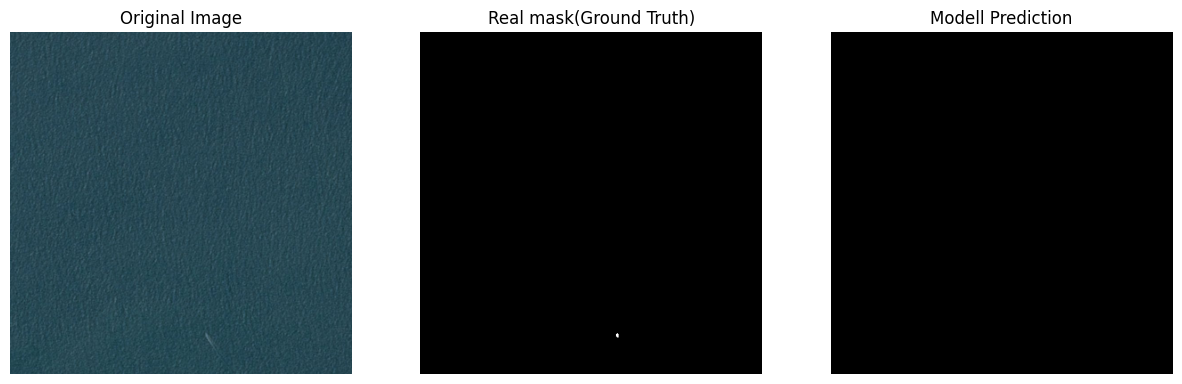

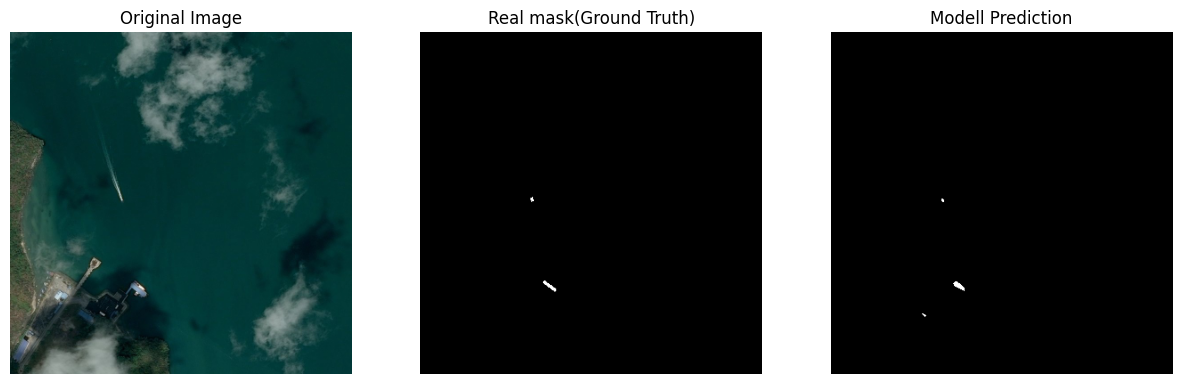

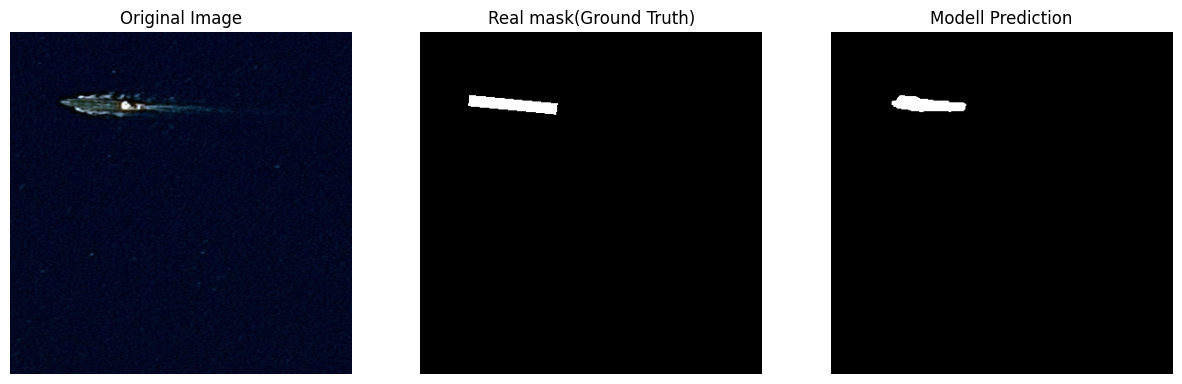

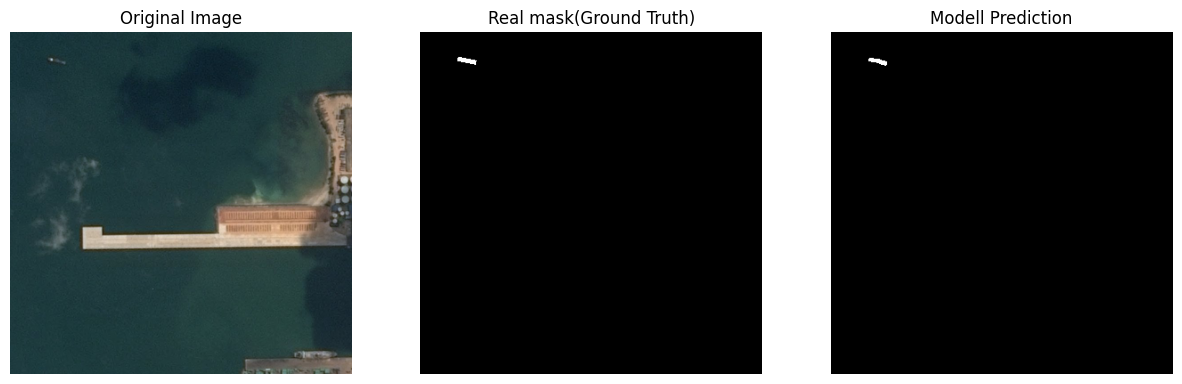

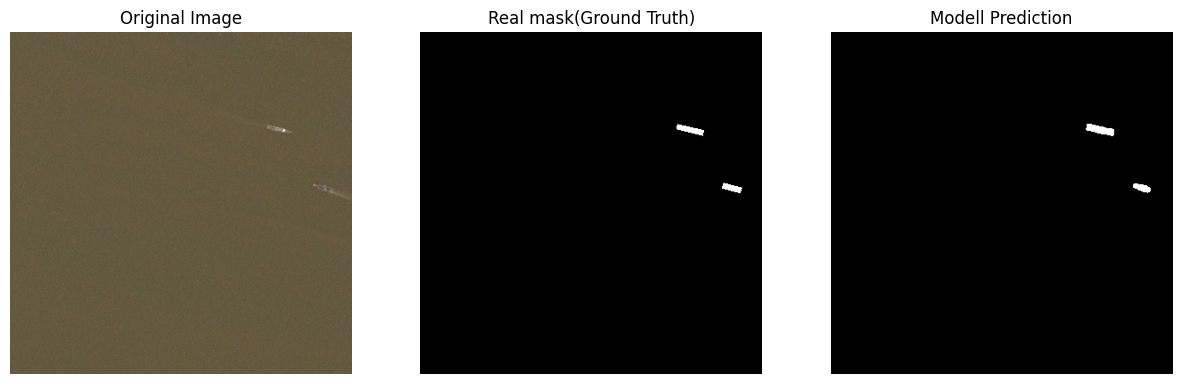

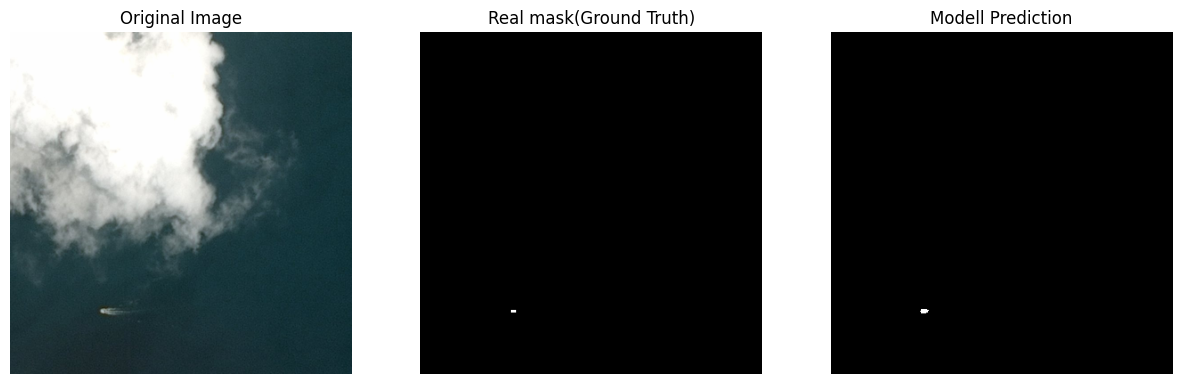

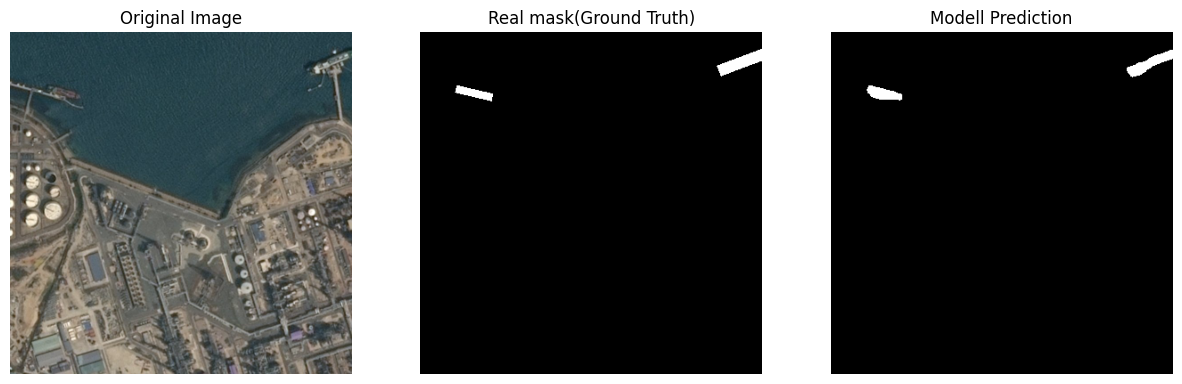

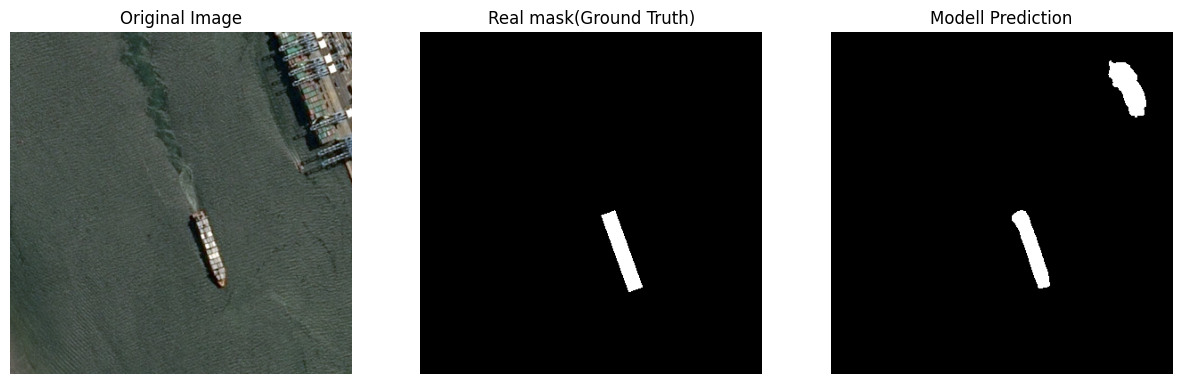

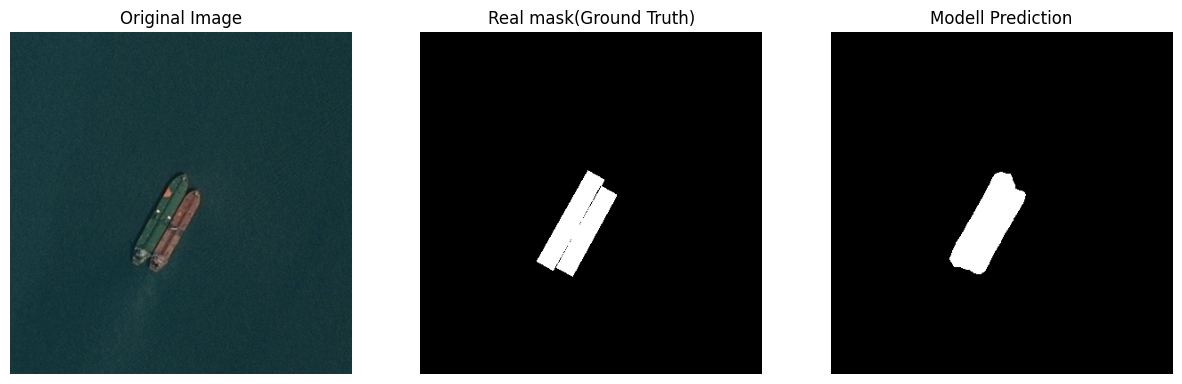

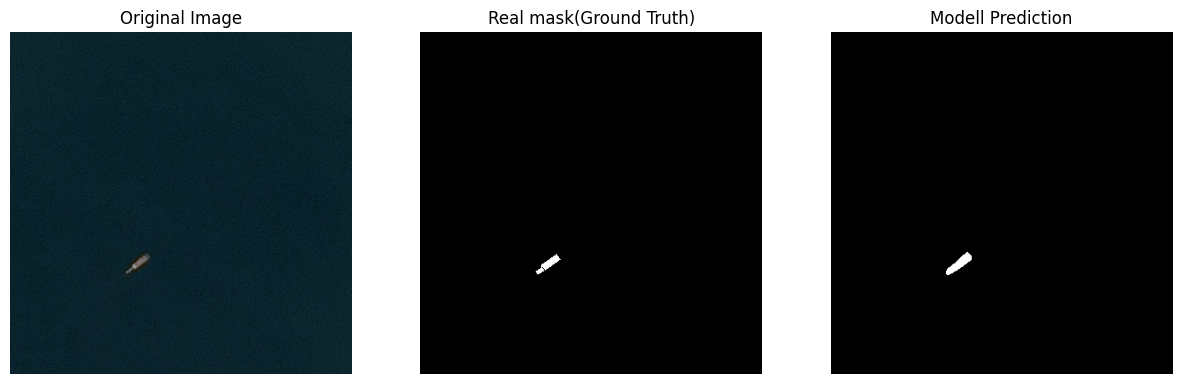

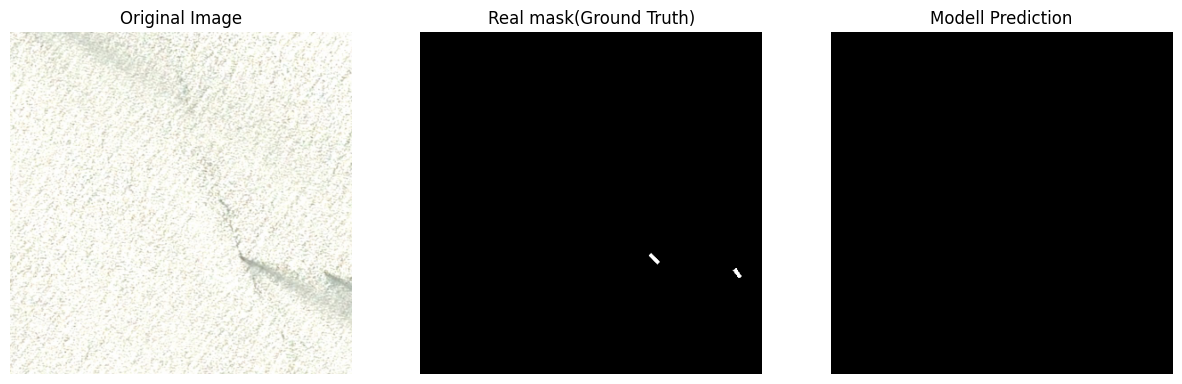

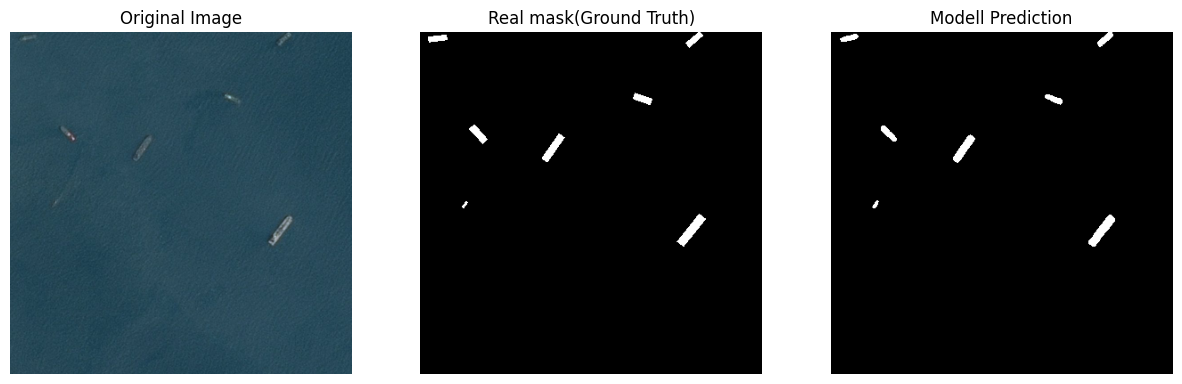

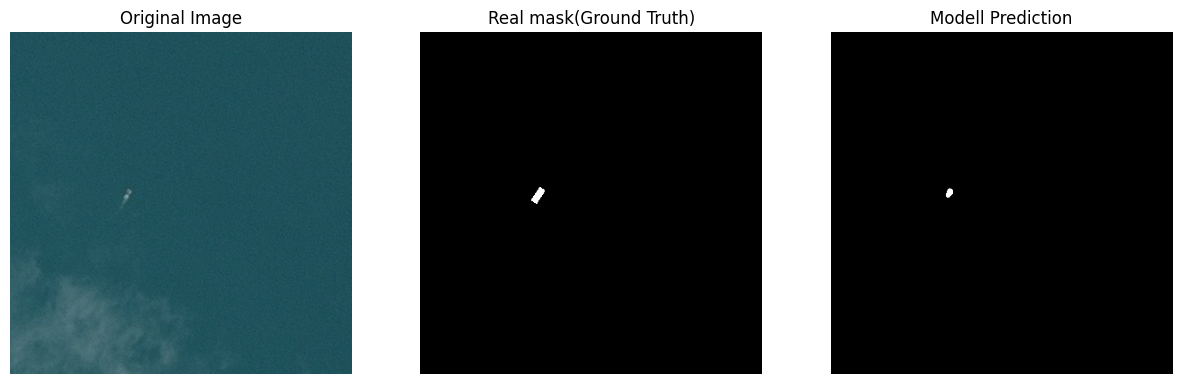

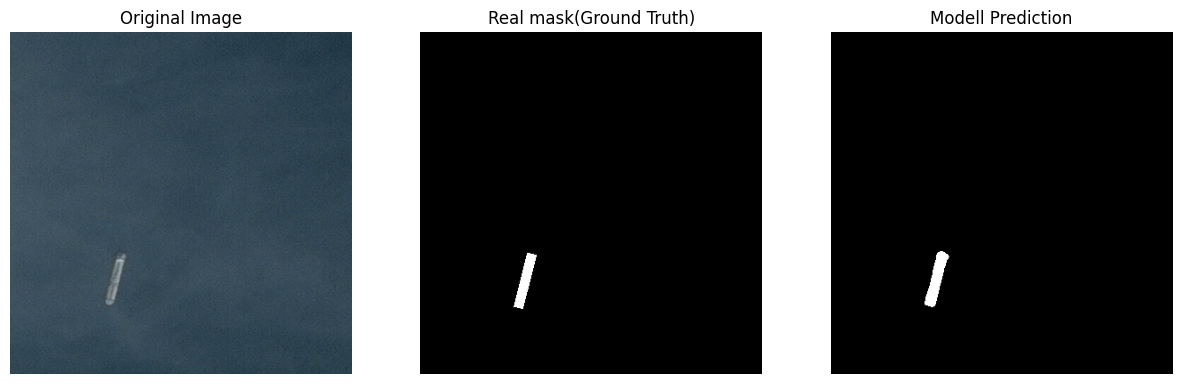

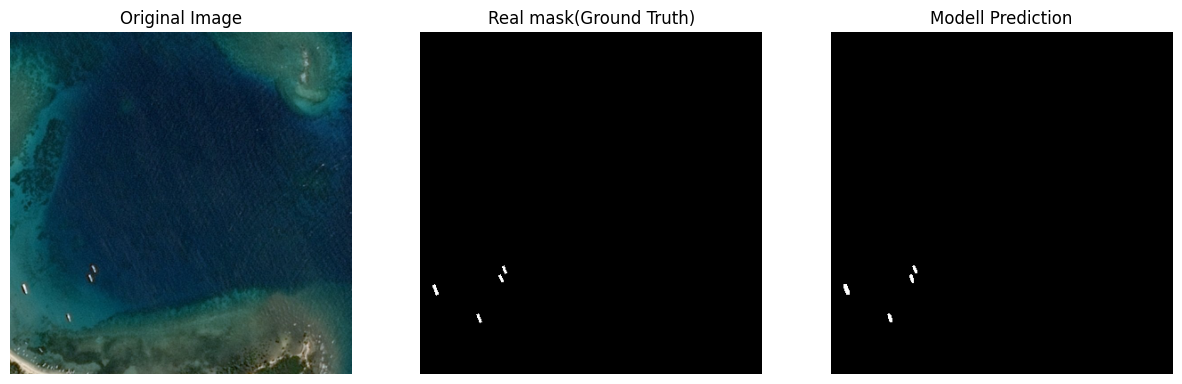

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def visualize_results(loader, model, device="cuda", num_samples=15):
    model.eval()

    samples_shown = 0

    with torch.no_grad():
        for x, y in loader:
            x = x.to(device)
            y = y.to(device).unsqueeze(1)
            preds = torch.sigmoid(model(x))
            preds = (preds > 0.5).float()

            # Vissza CPU-ra
            x = x.cpu().numpy()
            y = y.cpu().numpy()
            preds = preds.cpu().numpy()

            for i in range(x.shape[0]):
                # Only show pictures that have ships
                if y[i].sum() > 0:
                    if samples_shown >= num_samples:
                        return

                    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 5))

                    # Kép normalizálás visszaállítása (hogy látható legyen)
                    img = np.transpose(x[i], (1, 2, 0))
                    mean = np.array([0.485, 0.456, 0.406])
                    std = np.array([0.229, 0.224, 0.225])
                    img = std * img + mean
                    img = np.clip(img, 0, 1)

                    ax1.imshow(img)
                    ax1.set_title("Original Image")
                    ax1.axis("off")

                    ax2.imshow(y[i][0], cmap="gray")
                    ax2.set_title("Real mask(Ground Truth)")
                    ax2.axis("off")

                    ax3.imshow(preds[i][0], cmap="gray")
                    ax3.set_title("Modell Prediction")
                    ax3.axis("off")

                    plt.show()
                    samples_shown += 1

visualize_results(test_loader, model)

In [ ]:
gt_has_ship_map = (
    masks["EncodedPixels"]
    .notna()
    .groupby(masks["ImageId"])
    .any()
    .to_dict()
)

def gt_has_ship(image_id):
    return bool(gt_has_ship_map.get(image_id, False))


def evaluate_image_level_detection(
    loader,
    model,
    device="cuda",
    prob_threshold=0.4   # image-level threshold
):
    model.eval()

    TP = FP = TN = FN = 0

    with torch.no_grad():
        for batch_idx, (x, y) in enumerate(tqdm(loader)):
            x = x.to(device).float()

            logits = model(x)
            probs = torch.sigmoid(logits)   # [B,1,H,W]

            # image-level confidence (most robust)
            img_conf = probs.amax(dim=(1,2,3))  # [B]

            B = x.shape[0]
            for i in range(B):
                # image id from dataset (safe indexing)
                img_id = loader.dataset.image_ids[batch_idx * loader.batch_size + i]

                gt = gt_has_ship(img_id)
                pred = img_conf[i].item() > prob_threshold

                if pred and gt:
                    TP += 1
                elif pred and not gt:
                    FP += 1
                elif (not pred) and gt:
                    FN += 1
                else:
                    TN += 1

    # metrics
    precision = TP / (TP + FP + 1e-8)
    recall    = TP / (TP + FN + 1e-8)
    accuracy  = (TP + TN) / (TP + TN + FP + FN + 1e-8)

    print("\n--- Image-level detection results ---")
    print(f"TP={TP} | FP={FP} | FN={FN} | TN={TN}")
    print(f"Precision={precision:.4f}")
    print(f"Recall={recall:.4f}")
    print(f"Accuracy={accuracy:.4f}")

    model.train()
    return {
        "TP": TP, "FP": FP, "FN": FN, "TN": TN,
        "precision": precision,
        "recall": recall,
        "accuracy": accuracy
    }

results = evaluate_image_level_detection(
    loader=val_loader,
    model=model,
    device=DEVICE,
    prob_threshold=0.4   # tune this if needed
)



  0%|          | 0/320 [00:00<?, ?it/s]


--- Image-level detection results ---
TP=1889 | FP=67 | FN=239 | TN=4188
Precision=0.9657
Recall=0.8877
Accuracy=0.9521
